# CAA Model Replication - Group Data
Replicating results from Kang et al. using Table C3 DISP parameters.

Note: Default repository data contains 7,735 trials (filtered) vs 
9,876 trials in published results. This accounts for small differences 
in NLL (813.04 vs 804.75), AIC (1650 vs 1586) and BIC (1734 vs 1590).

In [1]:
from caa_model import dual_process as dp
from caa_model import newModel as nm

C:\Users\mbh32\AppData\Local\Programs\Python\Python312\Lib\shelve.py:114: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  value = Unpickler(f).load()


In [27]:
import matplotlib.pyplot as plt 
import numpy as np
import scipy as sp
from scipy import stats
import yaml

In [3]:
data = dp.DATA
c_high = [0.998, 0.0]
c = 0.998
mu_r = 0.002
mu_f = 0.306
d_r = 0.004
d_f = 0.374
tc_bound = 0.059
r_bound = 0.001
x0 = -0.131
mu_r0 = -0.014
mu_f0 = -0.244
deltaT = 0.586
t_offset = 0.513

# Replicating Figure 8 using MC Sims

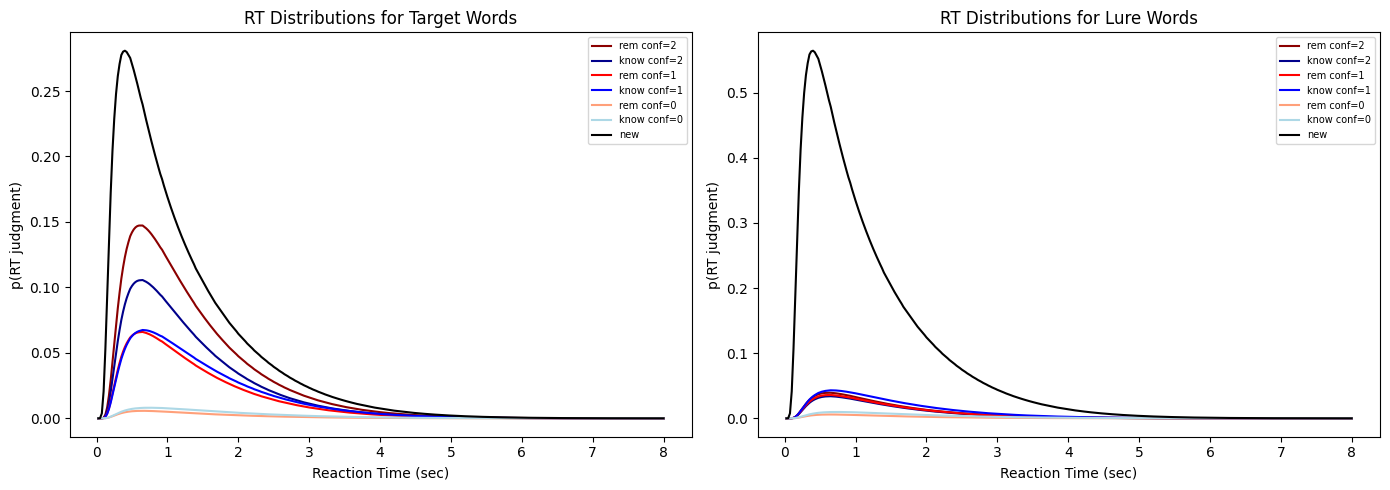

In [4]:
p_rem, p_know, p_new, t = dp.predicted_proportions(c_high, mu_r, mu_f, d_r, d_f, tc_bound, r_bound, x0, deltaT)
p_rem_lures, p_know_lures, p_new_lures, t = dp.predicted_proportions(
    c_high, mu_r0, mu_f0, d_r, d_f, tc_bound, r_bound, x0, deltaT
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

confidence_labels = ["conf=2", "conf=1", "conf=0"]
colors_rem = ["darkred", "red", "lightsalmon"]
colors_know = ["darkblue", "blue", "lightblue"]

for i in range(3):
    axes[0].plot(t, p_rem[i] / dp.DELTA_T, color=colors_rem[i], label=f"rem {confidence_labels[i]}")
    axes[0].plot(t, p_know[i] / dp.DELTA_T, color=colors_know[i], label=f"know {confidence_labels[i]}")
axes[0].plot(t, p_new / dp.DELTA_T, color="black", label="new")
axes[0].set_title("RT Distributions for Target Words")
axes[0].set_xlabel("Reaction Time (sec)")
axes[0].set_ylabel("p(RT judgment)")
axes[0].legend(fontsize=7)

for i in range(3):
    axes[1].plot(t, p_rem_lures[i] / dp.DELTA_T, color=colors_rem[i], label=f"rem {confidence_labels[i]}")
    axes[1].plot(t, p_know_lures[i] / dp.DELTA_T, color=colors_know[i], label=f"know {confidence_labels[i]}")
axes[1].plot(t, p_new_lures / dp.DELTA_T, color="black", label="new")
axes[1].set_title("RT Distributions for Lure Words")
axes[1].set_xlabel("Reaction Time (sec)")
axes[1].set_ylabel("p(RT judgment)")
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

# Using Predicted_Proportions

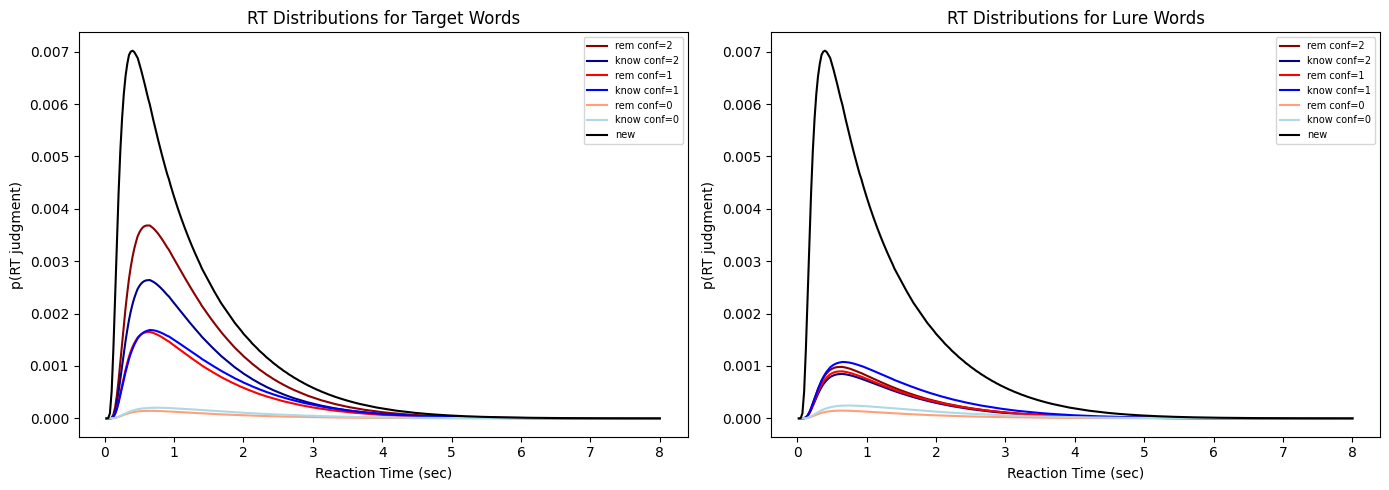

In [5]:
p_rem, p_know, p_new, t = dp.predicted_proportions(c_high, mu_r, mu_f, d_r, d_f, tc_bound, r_bound, x0, deltaT)

p_rem_lures, p_know_lures, p_new_lures, t = dp.predicted_proportions(c_high, mu_r0, mu_f0, d_r, d_f, tc_bound, r_bound, x0, deltaT)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

confidence_labels = ['conf=2', 'conf=1', 'conf=0']
colors_rem = ['darkred', 'red', 'lightsalmon']
colors_know = ['darkblue', 'blue', 'lightblue']

for i in range(3):
    axes[0].plot(t, p_rem[i], color=colors_rem[i], label = f'rem {confidence_labels[i]}')
    axes[0].plot(t, p_know[i], color=colors_know[i], label=f'know {confidence_labels[i]}')
axes[0].plot(t, p_new, color='black', label='new')
axes[0].set_title('RT Distributions for Target Words')
axes[0].set_xlabel('Reaction Time (sec)')
axes[0].set_ylabel('p(RT judgment)')
axes[0].legend(fontsize=7)

for i in range(3):
    axes[1].plot(t, p_rem_lures[i], color=colors_rem[i], label = f'rem {confidence_labels[i]}')
    axes[1].plot(t, p_know_lures[i], color=colors_know[i], label=f'know {confidence_labels[i]}')
axes[1].plot(t, p_new, color='black', label='new')
axes[1].set_title('RT Distributions for Lure Words')
axes[1].set_xlabel('Reaction Time (sec)')
axes[1].set_ylabel('p(RT judgment)')
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()


# Replicating Table 6 

In [6]:
data = dp.DATA

model_params = [c, mu_r, mu_f, d_r, d_f, tc_bound, r_bound, x0, mu_r0, mu_f0, deltaT, t_offset]

neg_log_lik = dp.compute_gof_all(model_params, use_chisq=False)
n_params = 12
n_data = (
    len(data.rem_hit.rt)
    + len(data.know_hit.rt)
    + len(data.CR.rt)
    + len(data.miss.rt)
    + len(data.rem_fa.rt)
    + len(data.know_fa.rt)
)

print(f"N data points: {n_data}")

AIC = 2 * n_params + 2 * neg_log_lik
BIC = n_params * np.log(n_data) + 2 * neg_log_lik

print(f"Negative log likelihood: {neg_log_lik:.2f}")
print(f"AIC: {AIC:.0f}")
print(f"BIC: {BIC:.0f}")

N data points: 7735
Negative log likelihood: 813.04
AIC: 1650
BIC: 1734


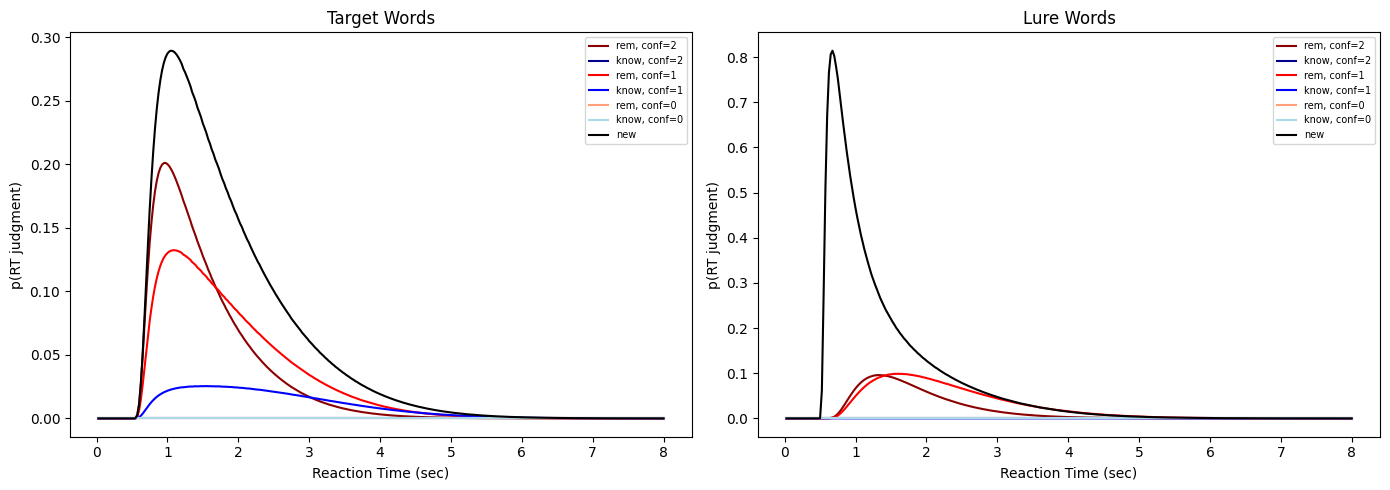

In [7]:
c_high     = [0.998, 0]
mu_r       = 0.05
d          = 0.35
tc_bound   = 0.1
r_bound_offset = 0.7
z0         = 0.02
deltaT     = 0.059
sigma_z0   = 0.002
t0         = 0.51
z0_l       = -0.45
mu_r_l     = 0.1

# targets
p_rem, p_know, p_new, t = nm.predicted_proportions(
    c_high, mu_r, d, tc_bound, r_bound_offset, z0, deltaT, sigma_z0, t0)

# lures
p_rem_l, p_know_l, p_new_l, t = nm.predicted_proportions(
    c_high, mu_r_l, d, tc_bound, r_bound_offset, z0_l, deltaT, sigma_z0, t0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
confidence_labels = ['conf=2', 'conf=1', 'conf=0']
colors_rem  = ['darkred', 'red', 'lightsalmon']
colors_know = ['darkblue', 'blue', 'lightblue']

for i in range(3):
    axes[0].plot(t, p_rem[i]  / nm.DELTA_T, color=colors_rem[i],  label=f'rem, {confidence_labels[i]}')
    axes[0].plot(t, p_know[i] / nm.DELTA_T, color=colors_know[i], label=f'know, {confidence_labels[i]}')
axes[0].plot(t, p_new / nm.DELTA_T, color='black', label='new')
axes[0].set_title('Target Words')
axes[0].set_xlabel('Reaction Time (sec)')
axes[0].set_ylabel('p(RT judgment)')
axes[0].legend(fontsize=7)

for i in range(3):
    axes[1].plot(t, p_rem_l[i]  / nm.DELTA_T, color=colors_rem[i],  label=f'rem, {confidence_labels[i]}')
    axes[1].plot(t, p_know_l[i] / nm.DELTA_T, color=colors_know[i], label=f'know, {confidence_labels[i]}')
axes[1].plot(t, p_new_l / nm.DELTA_T, color='black', label='new')
axes[1].set_title('Lure Words')
axes[1].set_xlabel('Reaction Time (sec)')
axes[1].set_ylabel('p(RT judgment)')
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

# CAA Parameter Fitting

### NOTE: CURRENTLY, WE ARE FITTING ON ENTIRE DATASET. WE ARE NOT ACCOUNTING FOR z0 CHANGING WITH NOVELTY. GRAPH SHOULD BE SIMILAR TO SINGLE PROCESS.

## Fitting

In [8]:
# Optimize over entire data
# caa_opt = nm.find_ml_params_all()
# params_est = nm.CAAParams(*caa_opt.x)

params_est = nm.CAAParams(
    1.7802366345277048,
    1.0732968669582117,
    0.17804995041166943,
    0.5326415575619126,
    0.043589790458315514,
    0.9574460424899932,
    -0.690027580392909,
    -0.565893039286282,
    1.5546604244949078,
    0.12666843828878627,
    0.46706560655302104,
)

In [9]:
# params_opt = nm.find_ml_params_all_lm()
# RuntimeWarning: Maximum number of function evaluations has been exceeded.
# params_opt = nm.CAAParams(*params_opt)

params_opt = nm.CAAParams(
    1.59924242,
    1.0738145,
    0.18701977,
    0.53805349,
    0.04055546,
    1.23471973,
    -0.69547039,
    -0.58773088,
    1.58573168,
    0.12026633,
    0.48749629,
)

In [10]:
nm.compute_gof_all(params_opt, use_chisq=True)

np.float64(81109267240.55455)

## Evaluating

In [11]:
target_params = [
    [params_opt.c, 0],
    params_opt.mu_t,
    params_opt.d,
    params_opt.tc_bound,
    params_opt.r_bound_offset,
    params_opt.z0_t,
    params_opt.deltaT,
    params_opt.sigma_z0,
    params_opt.t0,
]

lure_params = [
    [params_opt.c, 0],
    params_opt.mu_l,
    params_opt.d,
    params_opt.tc_bound,
    params_opt.r_bound_offset,
    params_opt.z0_l,
    params_opt.deltaT,
    params_opt.sigma_z0,
    params_opt.t0,
]

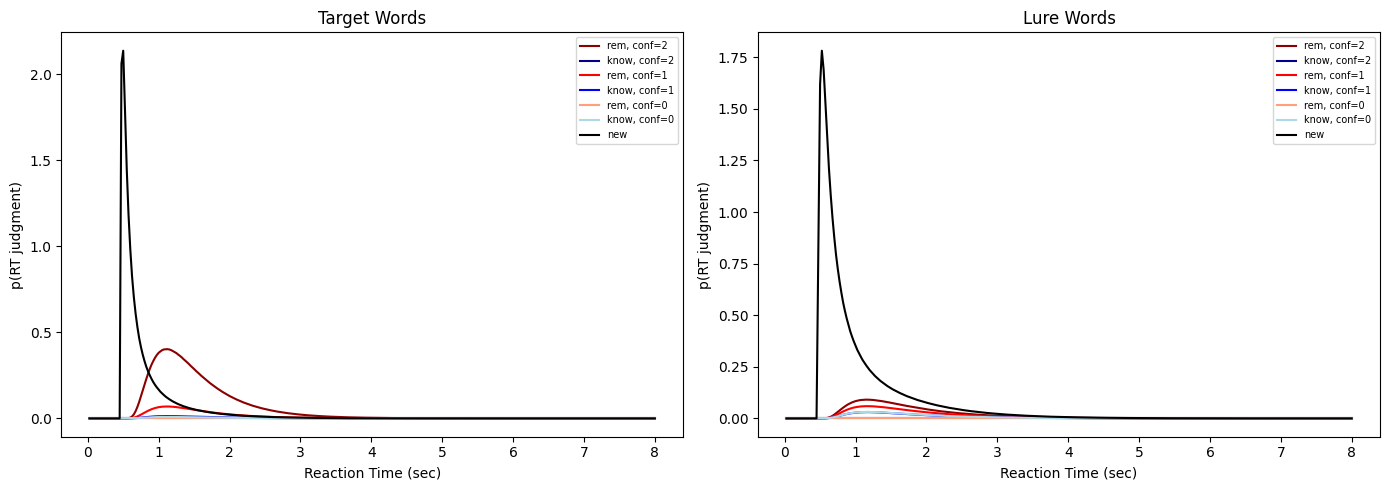

In [12]:
p_rem_t, p_know_t, p_new_t, t_t = nm.predicted_proportions(*target_params)
p_rem_l, p_know_l, p_new_l, t_l = nm.predicted_proportions(*lure_params)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
confidence_labels = ["conf=2", "conf=1", "conf=0"]
colors_rem = ["darkred", "red", "lightsalmon"]
colors_know = ["darkblue", "blue", "lightblue"]

for i in range(3):
    axes[0].plot(t_t, p_rem_t[i] / nm.DELTA_T, color=colors_rem[i], label=f"rem, {confidence_labels[i]}")
    axes[0].plot(t_t, p_know_t[i] / nm.DELTA_T, color=colors_know[i], label=f"know, {confidence_labels[i]}")
axes[0].plot(t_t, p_new_t / nm.DELTA_T, color="black", label="new")
axes[0].set_title("Target Words")
axes[0].set_xlabel("Reaction Time (sec)")
axes[0].set_ylabel("p(RT judgment)")
axes[0].legend(fontsize=7)

for i in range(3):
    axes[1].plot(t_l, p_rem_l[i] / nm.DELTA_T, color=colors_rem[i], label=f"rem, {confidence_labels[i]}")
    axes[1].plot(t_l, p_know_l[i] / nm.DELTA_T, color=colors_know[i], label=f"know, {confidence_labels[i]}")
axes[1].plot(t_l, p_new_l / nm.DELTA_T, color="black", label="new")
axes[1].set_title("Lure Words")
axes[1].set_xlabel("Reaction Time (sec)")
axes[1].set_ylabel("p(RT judgment)")
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

In [29]:
data = nm.DATA

neg_log_lik = nm.compute_gof_all(params_opt, use_chisq=False)
n_params = len(params_opt)
n_data = (
    len(data.rem_hit.rt)
    + len(data.know_hit.rt)
    + len(data.CR.rt)
    + len(data.miss.rt)
    + len(data.rem_fa.rt)
    + len(data.know_fa.rt)
)

print(f"N data points: {n_data}")

AIC = 2 * n_params + 2 * neg_log_lik
BIC = n_params * np.log(n_data) + 2 * neg_log_lik

print(f"Negative log likelihood: {neg_log_lik:.2f}")
print(f"AIC: {AIC:.0f}")
print(f"BIC: {BIC:.0f}")

N data points: 7735
Negative log likelihood: 20781.98
AIC: 41586
BIC: 41662


# Actual RT Graph

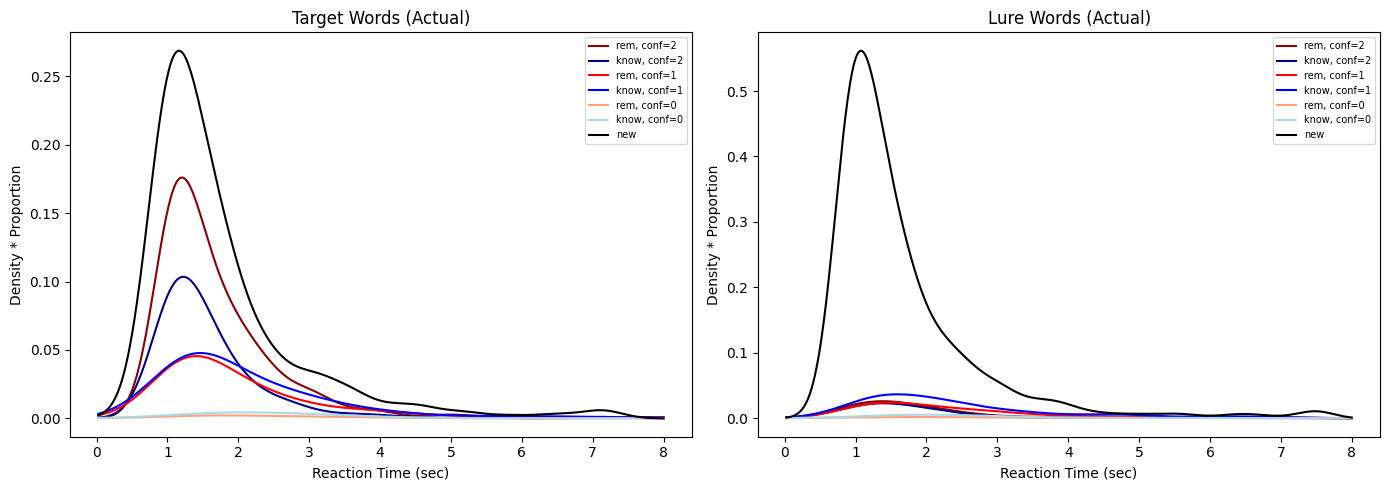

In [28]:
# Assuming data is loaded via nm.DATA (or dp.DATA)
data = nm.DATA

# Calculate total N for Targets and Lures to normalize the densities
N_target = len(data.rem_hit.rt) + len(data.know_hit.rt) + len(data.miss.rt)
N_lure = len(data.rem_fa.rt) + len(data.know_fa.rt) + len(data.CR.rt)

# Create a time axis for the KDE matching your model's maximum time
t_eval = np.linspace(nm.DELTA_T, nm.MAX_T, 500)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
confidence_labels = ["conf=2", "conf=1", "conf=0"]

# We map the loop index to the actual confidence ratings in the data (2, 1, 0)
conf_vals = [2, 1, 0] 

colors_rem = ["darkred", "red", "lightsalmon"]
colors_know = ["darkblue", "blue", "lightblue"]

def plot_empirical_kde(ax, rt_data, total_N, color, label):
    """Generates a KDE for the RTs and scales it by its proportion of total trials."""
    if len(rt_data) > 1: # KDE requires at least a few data points
        try:
            kde = stats.gaussian_kde(rt_data)
            # Scale the density curve by the relative frequency of this response
            scaled_density = kde(t_eval) * (len(rt_data) / total_N)
            ax.plot(t_eval, scaled_density, color=color, label=label)
        except np.linalg.LinAlgError:
            pass # Skips plotting if there is zero variance in the small bin

# --- Target Words (Empirical) ---
for i, conf_val in enumerate(conf_vals):
    # Remember Hits
    rt_subset_rem = data.rem_hit.rt[data.rem_hit.conf == conf_val]
    plot_empirical_kde(axes[0], rt_subset_rem, N_target, colors_rem[i], f"rem, {confidence_labels[i]}")
    
    # Know Hits
    rt_subset_know = data.know_hit.rt[data.know_hit.conf == conf_val]
    plot_empirical_kde(axes[0], rt_subset_know, N_target, colors_know[i], f"know, {confidence_labels[i]}")

# Misses (Actual "New" responses to Targets)
plot_empirical_kde(axes[0], data.miss.rt, N_target, "black", "new")

axes[0].set_title("Target Words (Actual)")
axes[0].set_xlabel("Reaction Time (sec)")
axes[0].set_ylabel("Density * Proportion")
axes[0].legend(fontsize=7)

# --- Lure Words (Empirical) ---
for i, conf_val in enumerate(conf_vals):
    # Remember False Alarms
    rt_subset_rem = data.rem_fa.rt[data.rem_fa.conf == conf_val]
    plot_empirical_kde(axes[1], rt_subset_rem, N_lure, colors_rem[i], f"rem, {confidence_labels[i]}")
    
    # Know False Alarms
    rt_subset_know = data.know_fa.rt[data.know_fa.conf == conf_val]
    plot_empirical_kde(axes[1], rt_subset_know, N_lure, colors_know[i], f"know, {confidence_labels[i]}")

# Correct Rejections (Actual "New" responses to Lures)
plot_empirical_kde(axes[1], data.CR.rt, N_lure, "black", "new")

axes[1].set_title("Lure Words (Actual)")
axes[1].set_xlabel("Reaction Time (sec)")
axes[1].set_ylabel("Density * Proportion")
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()